# Modeling liver fibrosis in NHANES — CAP steatosis-cutoff sensitivity

**Question.** When we define MASLD fibrosis as *fibrosis stage gated on hepatic steatosis*
(CAP ≥ cutoff), how much do the prevalence estimates and the coupling to metabolic risk
depend on **which** CAP cutoff we pick? Published cutoffs disagree, so this matters.

**Cohort.** NHANES 2017–March 2020 pre-pandemic, adults 18+ with a complete FibroScan
exam (`LUAXSTAT == 1`), MEC-weighted (`WTMECPRP`). n ≈ 7,767.

**Fibrosis stages (LSM, kPa).** F0 <6 · F1 6–<8 · F2 8–<10 · F3 10–<15 · F4 ≥15.

**CAP cutoff ladder (dB/m), labeled by source and steatosis level.** The first column,
`CAP≥0`, applies **no** steatosis gate (every FibroScan-scanned adult is staged) and is the
reference. Cutoffs then rise through the published range:

| dB/m | Source | Steatosis level |
|---|---|---|
| 0 | — | no gate (reference) |
| 248 | Karlas 2017 IPD meta-analysis (mixed etiology) | ≥S1 (any steatosis) |
| 263 | clinical reference set | S1 (mild) |
| 268 | Karlas 2017 | ≥S2 (moderate) |
| 280 | Karlas 2017 | ≥S3 (severe) |
| 288 | clinical set / project baseline | ≈S2 (moderate) |
| 302 | de Lédinghen 2014 / Eddowes 2019 (NAFLD) | ≥S1 (any steatosis) |
| 330 | clinical reference set | S3 (severe) |

Note that 248 and 302 are *both* "any steatosis" cutoffs — the gap between them is the
population/etiology effect (mixed-etiology vs NAFLD-specific derivation), not a difference
in what grade they target. See the accompanying discussion for why cutoffs vary.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
%matplotlib inline
import pandas as pd
import fibrosis_lib as fl
import fibrosis_plots as fp
pd.set_option("display.max_columns", 40)

coh = fl.build_cohort()
print(f"cohort n = {len(coh)}")
print(f"steatosis prevalence at CAP>=288: {100*(coh.LUXCAPM>=288).mean():.1f}%")

cohort n = 7767
steatosis prevalence at CAP>=288: 34.4%


## 1. Prevalence under each cutoff (including a 'No MASLD' row)

Columns are the CAP cutoffs; rows are the mutually exclusive population categories
(they sum to 100% within each column) plus two clinical roll-ups. As the cutoff rises,
**No MASLD** grows and every MASLD-fibrosis stage shrinks.

In [2]:
prev = fl.prevalence_table(coh)
prev.to_csv("outputs/prevalence_by_cap_cutoff.csv")
prev

,CAP≥0 (no gate),248 Karlas (mixed) ≥S1 any,263 clinical set S1 mild,268 Karlas (mixed) ≥S2 mod,280 Karlas (mixed) ≥S3 sev,288 clinical / baseline S2 mod,302 de Ledinghen/Eddowes (NAFLD) ≥S1 any,330 clinical set S3 sev
No MASLD (no steatosis),0.0,43.6,51.5,53.8,61.3,65.9,72.7,84.1
Steatosis (any MASLD),100.0,56.4,48.5,46.2,38.7,34.1,27.3,15.9
MASLD F0,72.5,36.1,30.1,28.3,22.4,19.0,14.2,7.0
MASLD F1,18.3,12.5,11.2,10.8,9.5,8.7,7.3,4.8
MASLD F2,4.2,3.5,3.1,3.0,2.9,2.6,2.4,1.5
MASLD F3,3.2,2.7,2.7,2.6,2.4,2.4,2.1,1.6
MASLD F4,1.8,1.6,1.6,1.6,1.5,1.4,1.3,1.0
MASLD F2+ (significant),9.2,7.8,7.3,7.2,6.8,6.4,5.8,4.1
MASLD F3+ (advanced),5.0,4.3,4.2,4.1,3.9,3.8,3.4,2.6


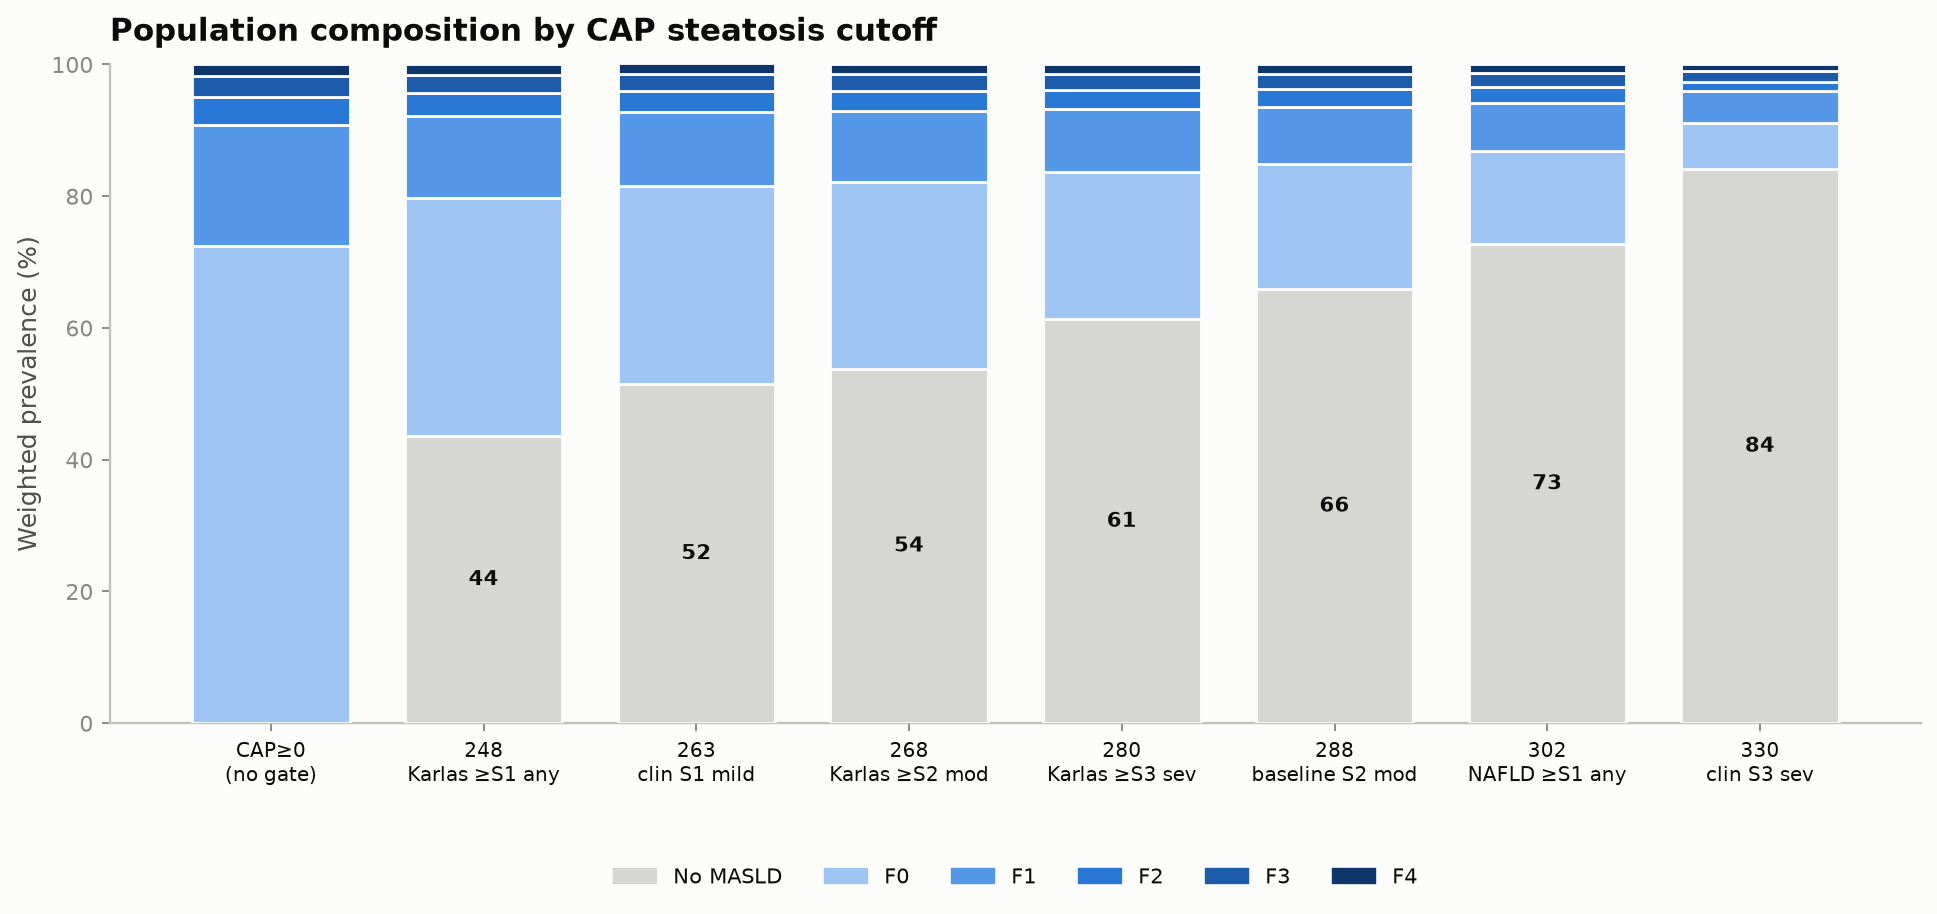

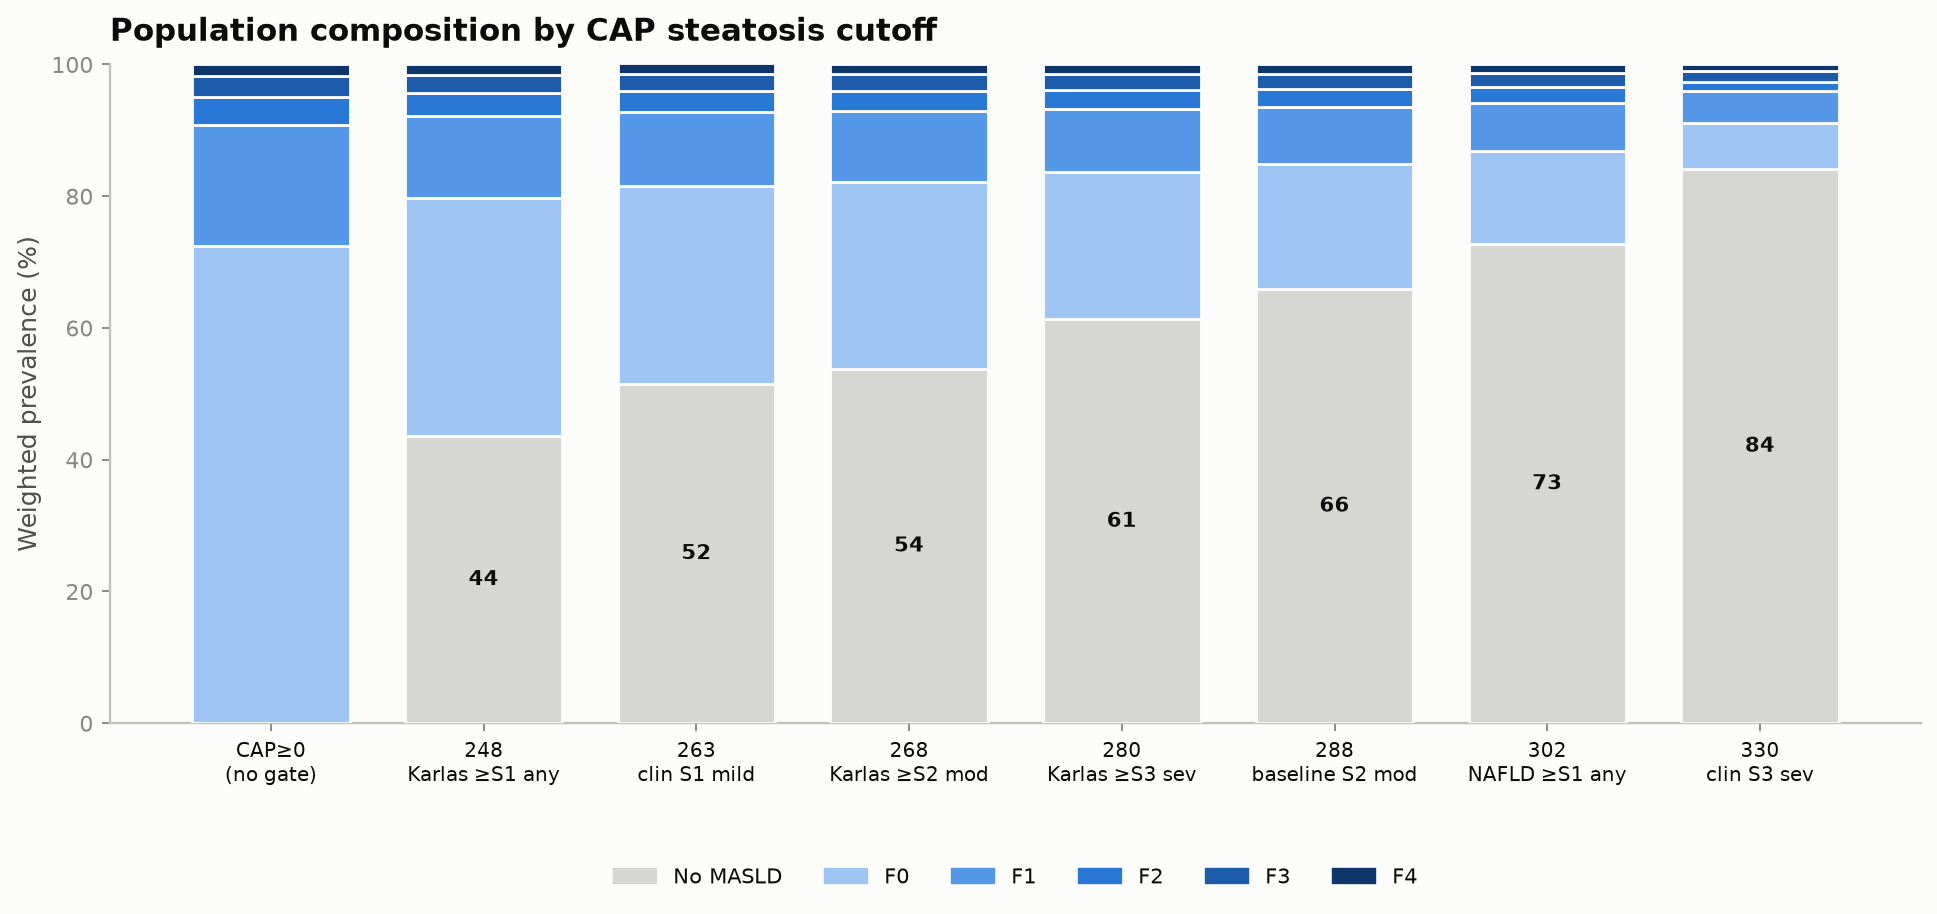

In [3]:
fp.prevalence_stacked(prev)

The headline **significant-fibrosis (F2+)** number slides smoothly with the cutoff —
from 9.2% with no gate to 4.1% at the most stringent (330) cutoff. The dotted line marks
the 288 baseline.

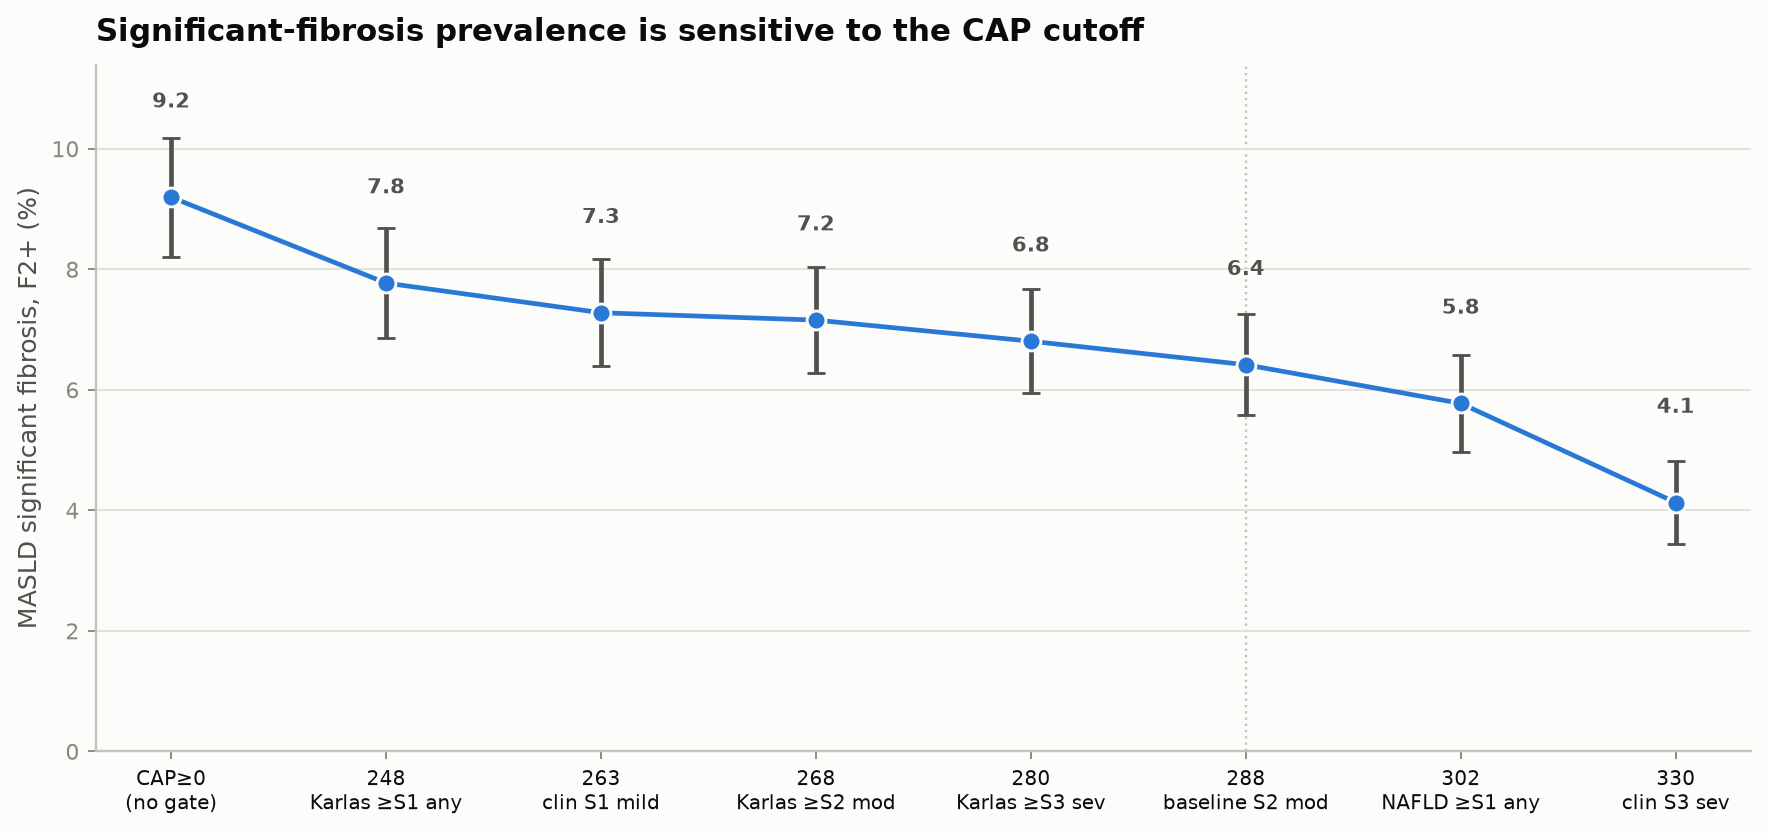

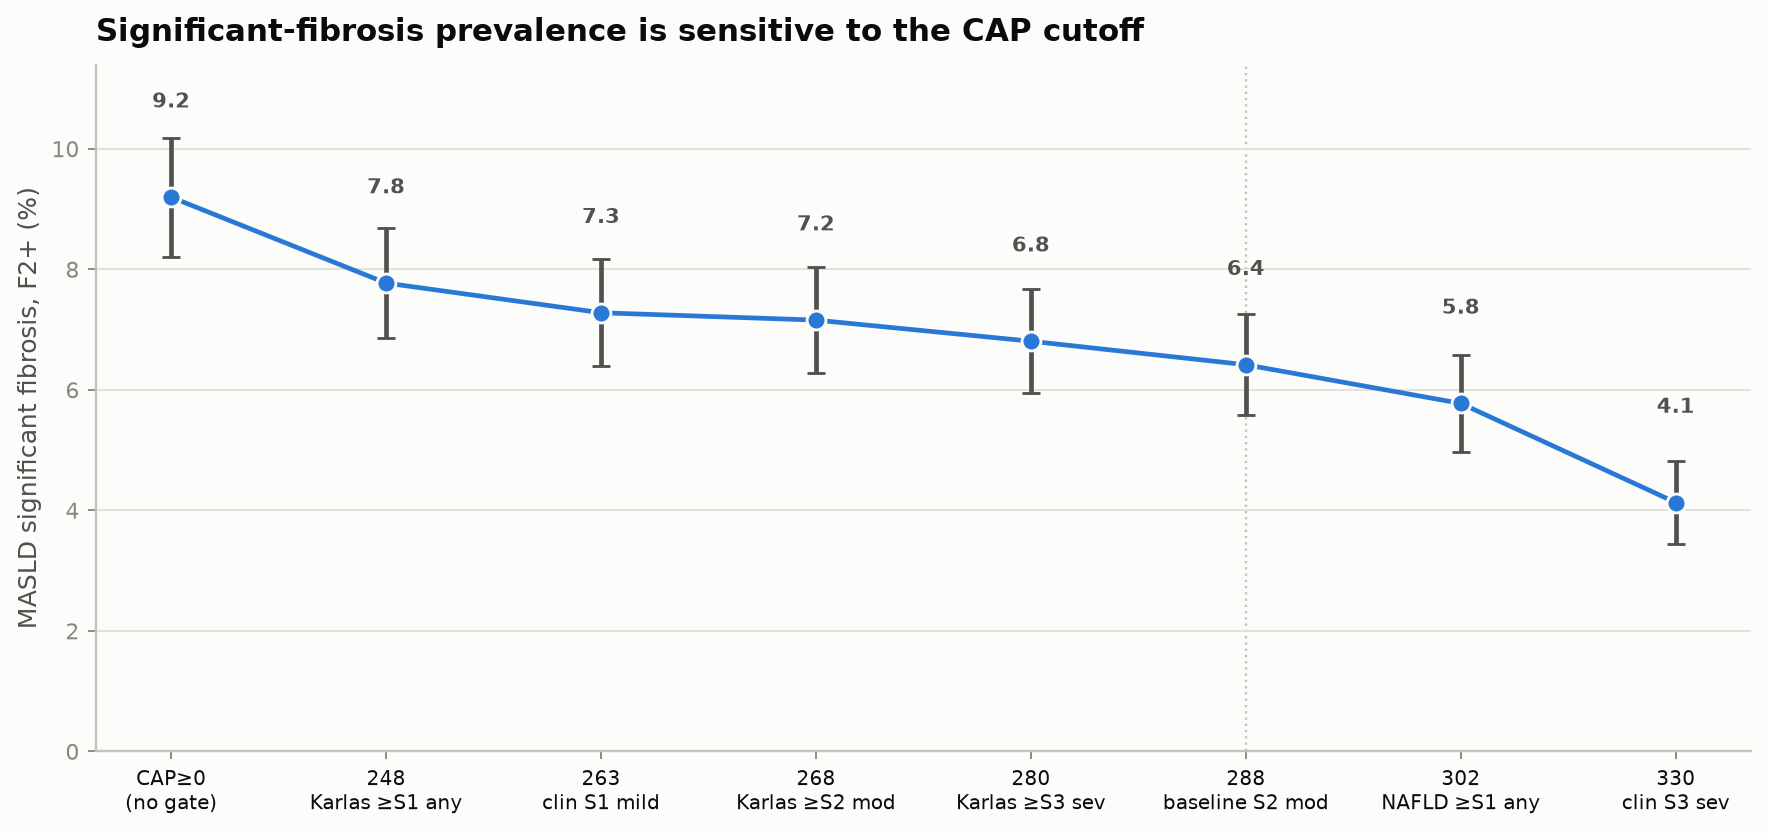

In [4]:
sens = fl.f2plus_sensitivity(coh)
fp.f2plus_sensitivity(sens)

## 2. Correlation with metabolic risk under each cutoff

Weighted Spearman ρ of each exposure with 11 cardiometabolic risk factors. The first two
columns are the **continuous** exposures (LSM = stiffness, CAP = steatosis) for reference;
the rest are the **categorical MASLD F-stage** gated at each cutoff.

Two things to read here: (a) continuous **CAP** carries far more metabolic signal than LSM;
(b) the gated F-stage's metabolic coupling is **not monotone** in the cutoff — it peaks at the
mild-steatosis cutoffs (~248–263) and falls again by 330, because an over-stringent gate
shrinks the MASLD group until the stage variable loses discrimination.

In [5]:
corr = fl.correlation_table(coh)
corr.to_csv("outputs/correlations_by_cap_cutoff.csv")
corr

,LSM (continuous),CAP (continuous),CAP≥0 (no gate),248 Karlas (mixed) ≥S1 any,263 clinical set S1 mild,268 Karlas (mixed) ≥S2 mod,280 Karlas (mixed) ≥S3 sev,288 clinical / baseline S2 mod,302 de Ledinghen/Eddowes (NAFLD) ≥S1 any,330 clinical set S3 sev
BMI,0.295,0.612,0.273,0.382,0.405,0.398,0.398,0.389,0.373,0.339
Waist,0.317,0.662,0.303,0.414,0.437,0.430,0.426,0.418,0.403,0.365
HbA1c,0.205,0.354,0.206,0.253,0.260,0.255,0.257,0.258,0.252,0.223
Fasting glucose,0.190,0.415,0.177,0.263,0.275,0.275,0.279,0.282,0.277,0.258
Triglycerides,0.123,0.456,0.102,0.212,0.234,0.230,0.225,0.227,0.227,0.203
HDL-C,-0.199,-0.361,-0.170,-0.229,-0.243,-0.240,-0.238,-0.238,-0.241,-0.214
ALT,0.239,0.367,0.215,0.244,0.261,0.262,0.257,0.256,0.258,0.230
AST,0.178,0.157,0.171,0.160,0.164,0.165,0.155,0.154,0.154,0.135
GGT,0.268,0.379,0.241,0.257,0.263,0.264,0.255,0.251,0.248,0.217
Systolic BP,0.168,0.219,0.129,0.147,0.143,0.142,0.130,0.127,0.135,0.121


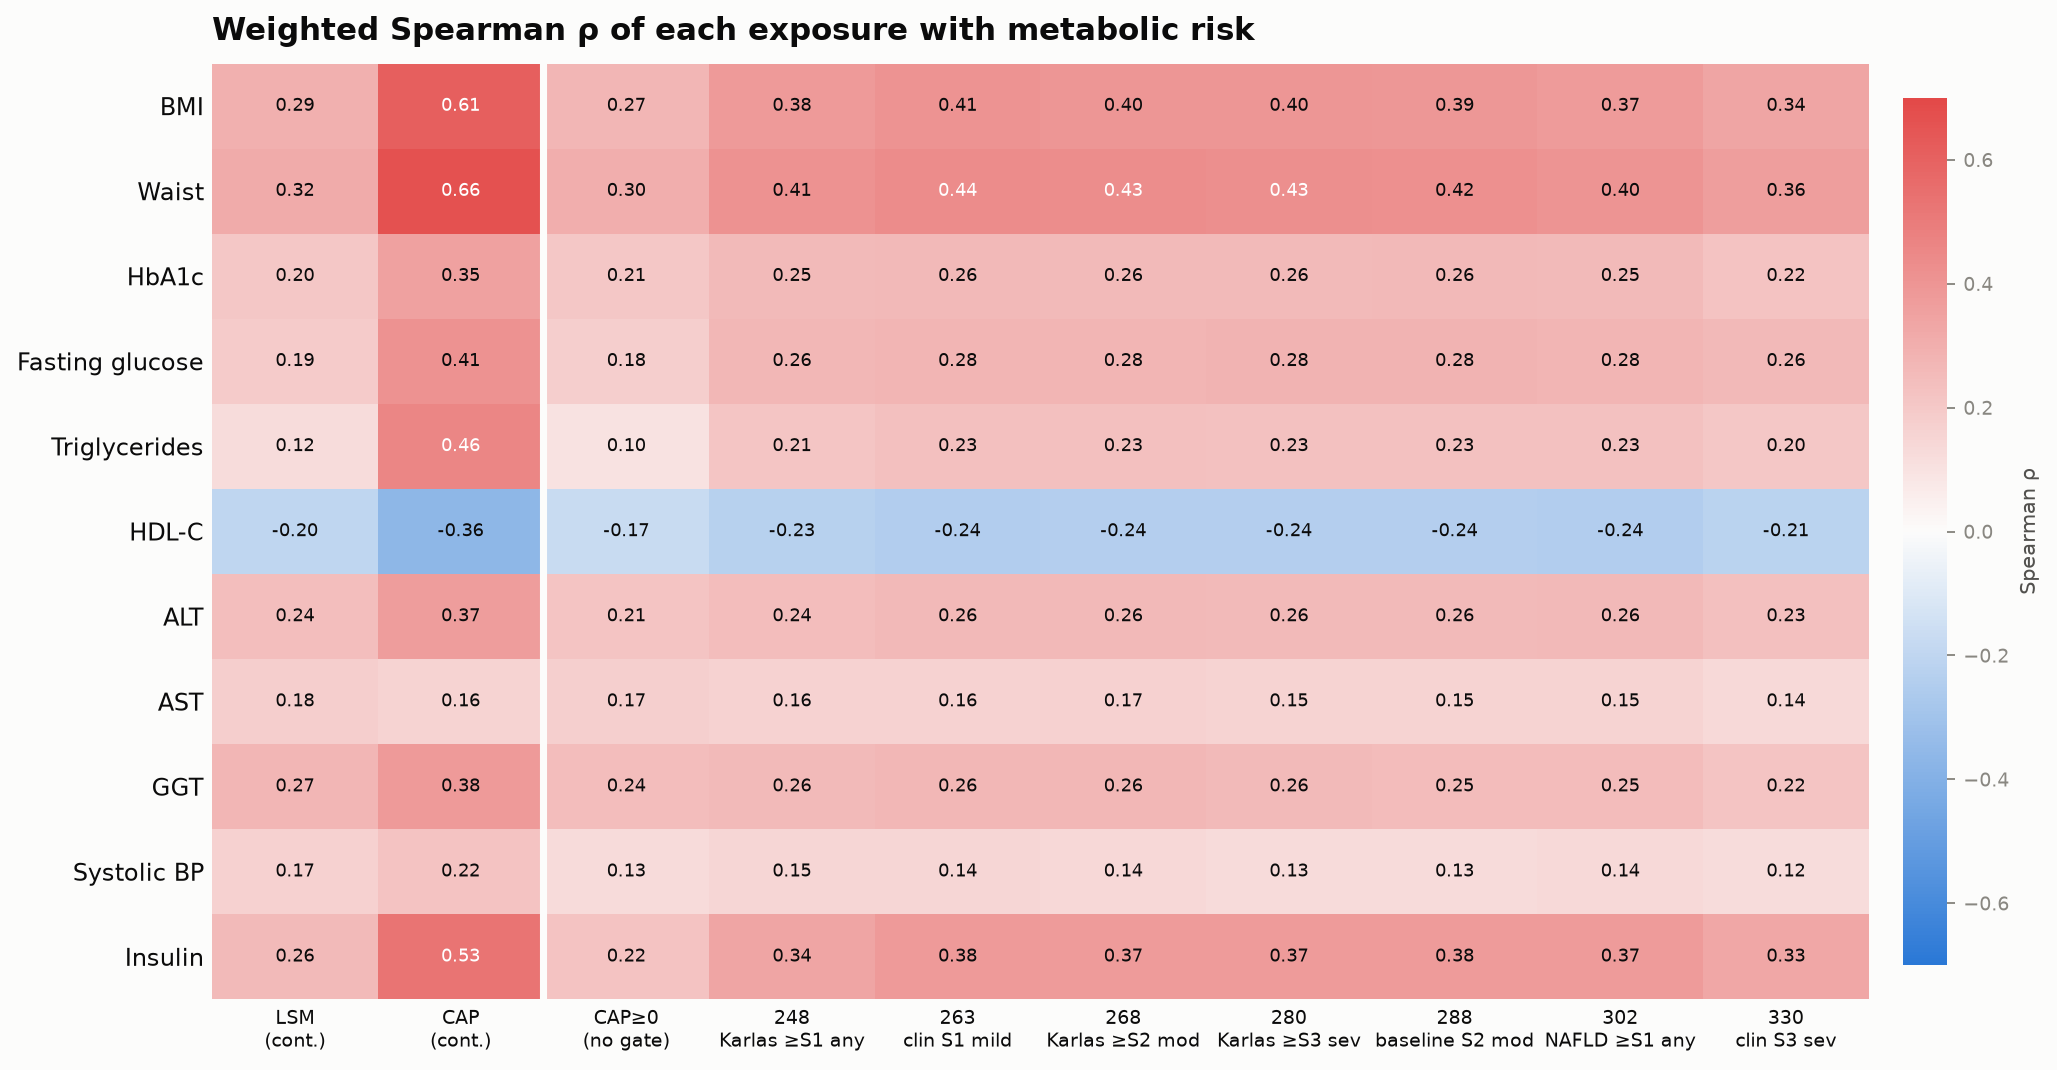

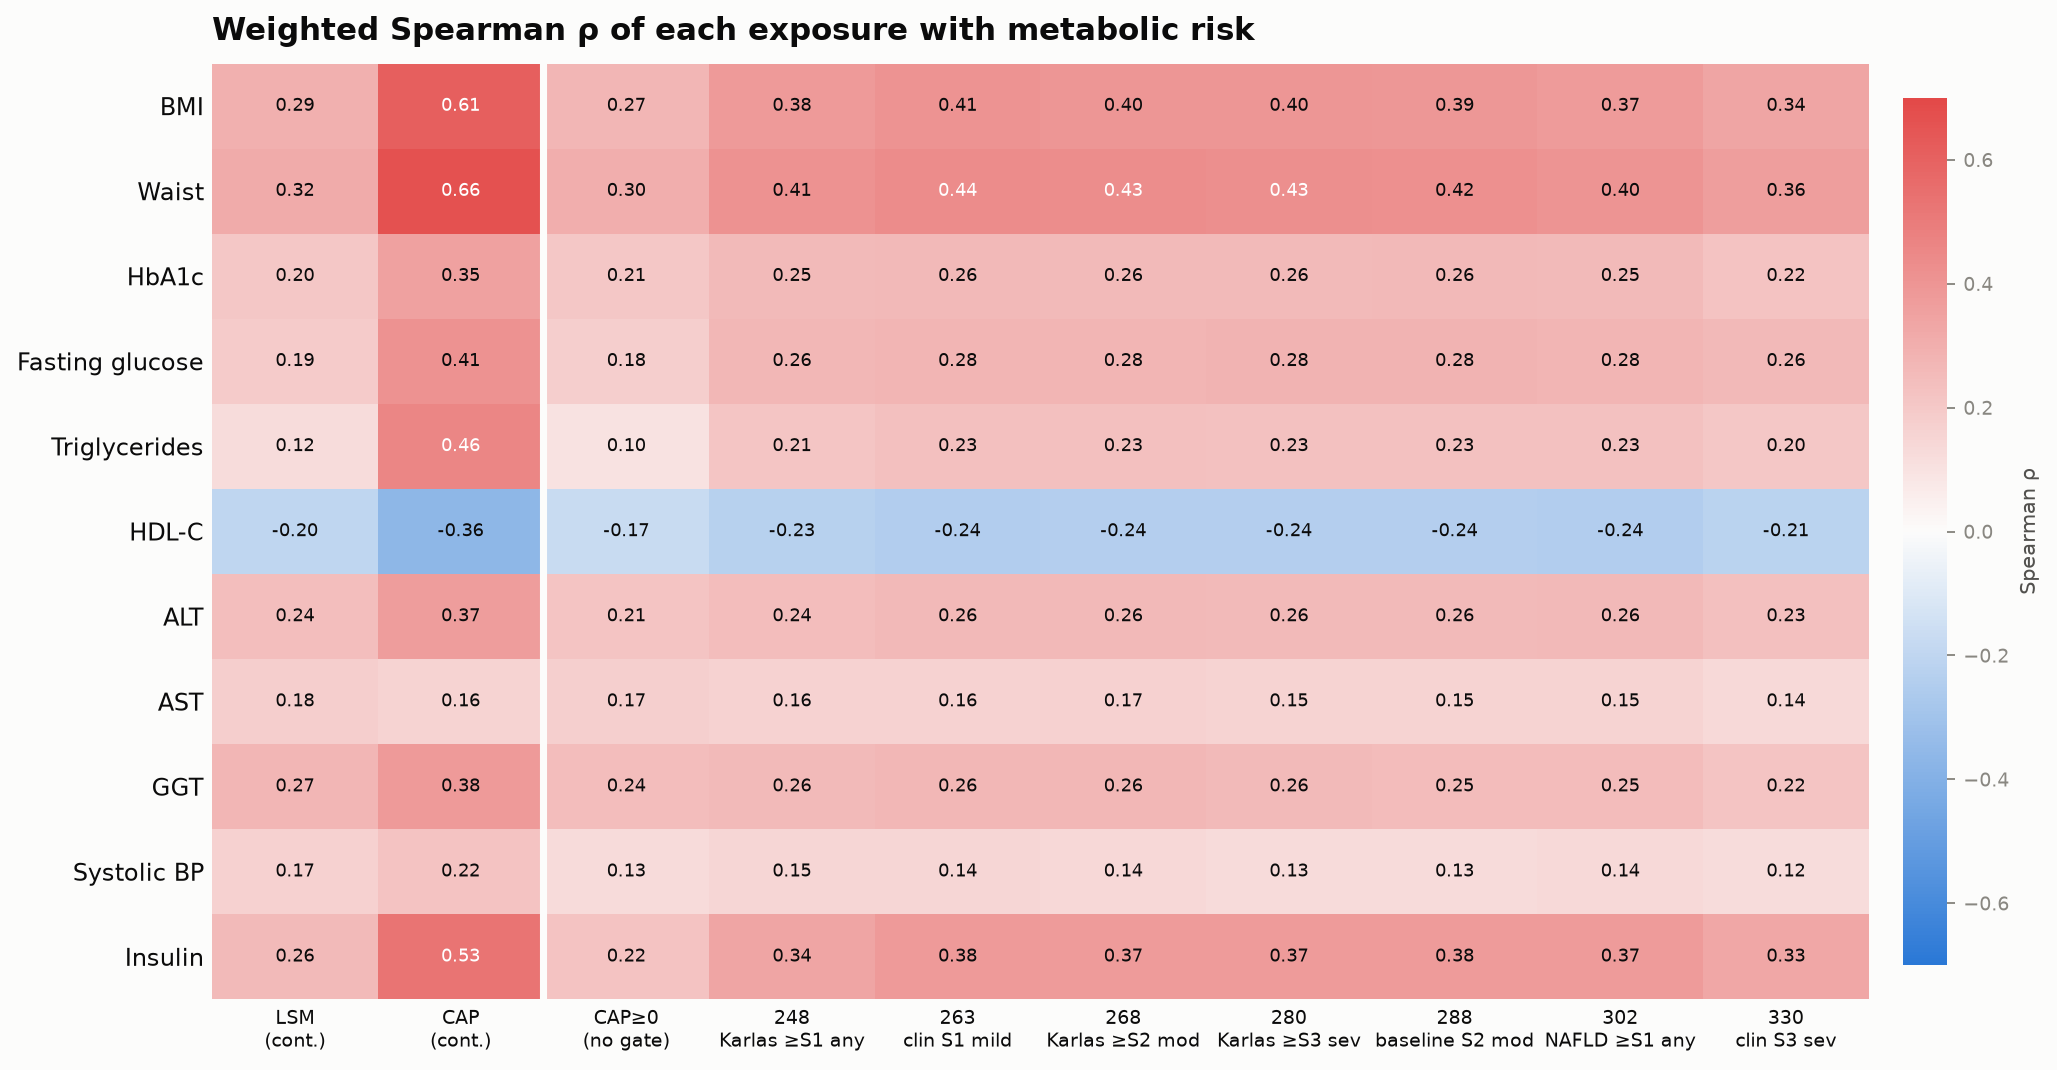

In [6]:
fp.correlation_heatmap(corr)

## Method & caveats

- **Weighting.** MEC weights (`WTMECPRP`); prevalences are population-weighted.
- **Correlations.** Weighted Spearman ρ (rank-transform, then MEC-weighted Pearson).
- **CIs** (on the F2+ figure) are analytic Fisher-z on the weight-based effective N; they do
  **not** account for PSU/stratum clustering, so full survey-design SEs would be modestly wider.
- **Fasting subsample.** Glucose, triglycerides, and insulin are measured only in the morning
  fasting subsample (~half the cohort); correlations use available pairs.
- **Cutoff attribution.** 248/268/280 are from the Karlas 2017 individual-patient-data
  meta-analysis (mixed etiology); 302 from de Lédinghen 2014 / Eddowes 2019 (NAFLD); the
  263/288/330 triple is a commonly-tabulated clinical set. CAP cutoffs legitimately differ by
  reference standard (histology grade vs MRI-PDFF), population/etiology, probe (M vs XL), and
  covariates — Karlas estimated CAP shifts of about +10 dB/m for NAFLD, +10 for diabetes, and
  +4.4 per BMI unit.